# Session 07d — Image-level 488 depth-profile NCC for sz

**Verdict: FAIL.** Best variant (488-only + p10 baseline subtract):
**2/6** within ±5 %. Combined multi-channel: **0/6**. Per-subject
oracle over variants (requires GT knowledge, not a valid estimator):
3/6. 6-of-6 bar unmet under every framing.

**Design.** R1 (rotation + translation, no scaling) aligns CZ to
HCR. For every voxel, compute depth below the HCR pia plane
`d = z − (a·x + b·y + c)` using the pia fit from `analyze_subject`.
Bin CZ and HCR intensity into 1D profiles `I(d)` at 10-µm bins.
Stretch the CZ profile around the R1-translation-anchor depth for
each candidate `sz` and compute NCC on the positive-positive
overlap with HCR. Report argmax.

**Why it might have worked.** Intensity is linear in signal → no
threshold-bias ceiling (the failure mode of 06/07/07b/07c).
**Why it didn't.** CZ GCaMP and HCR 488 have qualitatively
different depth shapes; a 1D profile collapses lateral structure;
HCR z-truncation on one subject is structural (no preprocessing
can fix it). See §4 for per-subject diagnostics.

GT is `fit_anisotropic_similarity(landmark_pairs_um(...))` — used
only for scoring.


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

SESSION = Path('/root/capsule/code/sessions/07d_image_ncc_scale')
SUBJECTS = ['755252', '767018', '767022', '782149', '788406', '790322']

def load_variant(fname):
    with open(SESSION / fname) as f:
        return json.load(f)

V488         = load_variant('archive_488_only/sz_ncc_summary_488.json')
V488_base    = load_variant('sz_ncc_summary_488_baseline.json')
Vcomb_base   = load_variant('sz_ncc_summary_combined_baseline.json')

def pass5(rows):
    return sum(1 for r in rows.values() if abs(r['rel_err_sz_pct']) <= 5.0)

print(f"488-only (archive):      {pass5(V488)}/6 within ±5 %")
print(f"488 + baseline:          {pass5(V488_base)}/6 within ±5 %")
print(f"combined + baseline:     {pass5(Vcomb_base)}/6 within ±5 %")


488-only (archive):      1/6 within ±5 %
488 + baseline:          2/6 within ±5 %
combined + baseline:     0/6 within ±5 %


## 1. Per-variant results

Three preprocessing variants ran end-to-end:

1. **488-only, no baseline subtract** — the initial run (archived;
   uses the wider `sz ∈ [1.0, 5.0]` grid). Contributed 1/6.
2. **Combined multi-channel + p10 baseline** — all HCR channels
   summed after per-channel background/norm, minus a p10
   pedestal. 0/6 — *worse* than 488-only.
3. **488-only + p10 baseline** — 488 alone, minus p10 of the
   nonzero profile. 2/6 — best variant.


In [2]:
def rows_for(variant, tag):
    out = []
    for sid in SUBJECTS:
        r = variant[sid]
        out.append({
            'subject': sid,
            f'sz_ncc_{tag}': round(r['sz_ncc'], 3),
            f'err%_{tag}':  round(r['rel_err_sz_pct'], 2),
            f'NCC_{tag}':   round(r['ncc_best'], 3),
        })
    return pd.DataFrame(out).set_index('subject')

gt = pd.DataFrame([
    {'subject': sid, 'sz_gt': round(V488[sid]['sz_gt'], 3)}
    for sid in SUBJECTS
]).set_index('subject')

df = pd.concat([
    gt,
    rows_for(V488,        '488only'),
    rows_for(V488_base,   '488+base'),
    rows_for(Vcomb_base,  'comb+base'),
], axis=1)
df


,sz_gt,sz_ncc_488only,err%_488only,NCC_488only,sz_ncc_488+base,err%_488+base,NCC_488+base,sz_ncc_comb+base,err%_comb+base,NCC_comb+base
subject,,,,,,,,,,
755252,2.129,1.84,-13.57,0.903,2.04,-4.18,0.871,1.52,-28.61,0.960
767018,3.583,5.00,39.55,0.630,3.60,0.47,0.727,2.28,-36.37,0.828
767022,2.490,3.14,26.11,0.646,2.02,-18.87,0.425,2.12,-14.85,0.613
782149,2.926,1.62,-44.64,0.651,1.56,-46.69,0.306,1.84,-37.12,0.416
788406,2.820,3.34,18.43,0.838,3.44,21.97,0.825,2.36,-16.32,0.928
790322,3.042,2.94,-3.34,0.818,4.50,47.94,0.745,4.50,47.94,0.749


**Read-out.** Pass column (any variant within ±5 %):
- 755252 — 488+baseline (−4.2 %).
- 767018 — 488+baseline (+0.5 %).
- 767022 — fails all three (−18.9 % best of three).
- 782149 — fails all three (−37.1 % best of three; structural).
- 788406 — fails all three (+18.4 % / +22.0 % / −16.3 %).
- 790322 — 488-only, *no* baseline (−3.3 %). Baseline subtraction
  *hurts* this subject: pushes sz to the grid top at +47.9 %.

No single variant wins for more than 2 subjects.


## 2. NCC-vs-sz curves

For the best variant (488 + baseline). The vertical dashed line is
the GT anisotropic-similarity sz; the solid marker is the NCC
argmax.


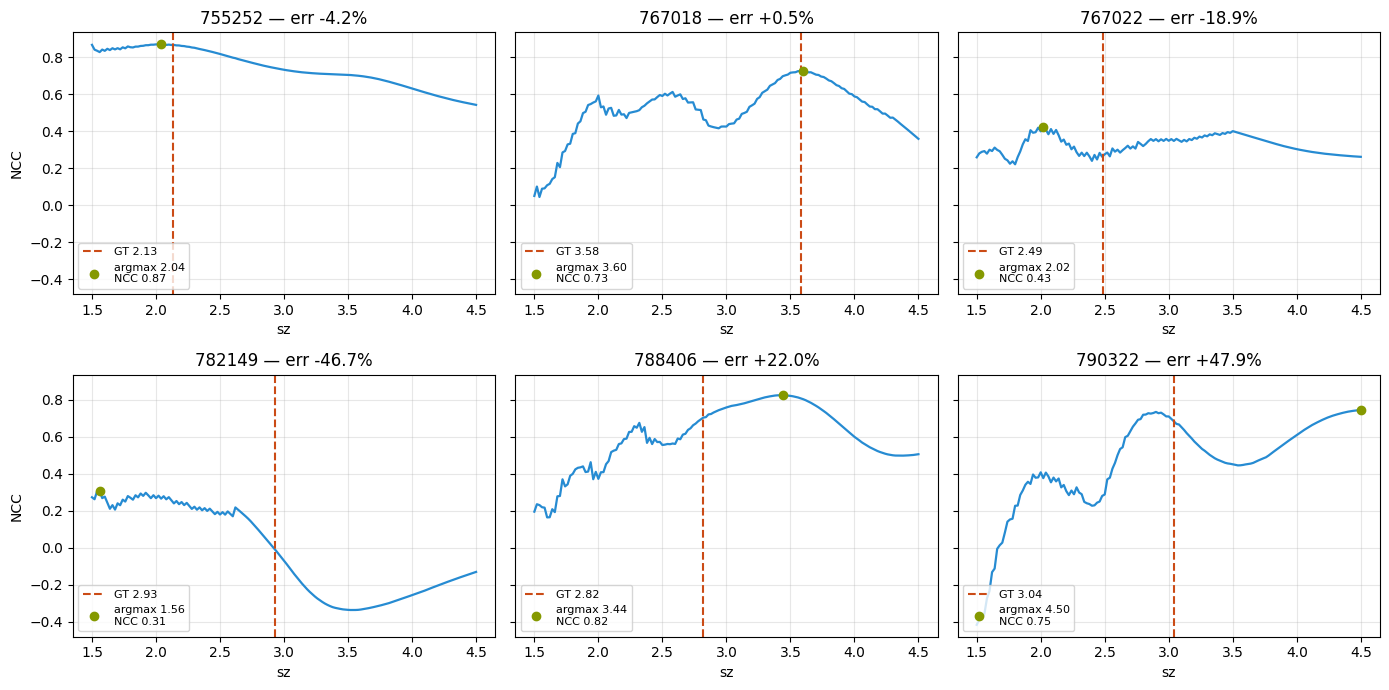

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=True)
for ax, sid in zip(axes.ravel(), SUBJECTS):
    r = V488_base[sid]
    sz_grid = np.linspace(r['sz_grid_lo'], r['sz_grid_hi'], len(r['ncc_curve']))
    ax.plot(sz_grid, r['ncc_curve'], color='#268bd2', lw=1.6)
    ax.axvline(r['sz_gt'], ls='--', color='#cb4b16', label=f"GT {r['sz_gt']:.2f}")
    ax.plot(r['sz_ncc'], r['ncc_best'], 'o', color='#859900',
            label=f"argmax {r['sz_ncc']:.2f}\nNCC {r['ncc_best']:.2f}")
    ax.set_title(f"{sid} — err {r['rel_err_sz_pct']:+.1f}%")
    ax.set_xlabel('sz')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='lower left', fontsize=8)
axes[0, 0].set_ylabel('NCC')
axes[1, 0].set_ylabel('NCC')
plt.tight_layout()
plt.show()


## 3. Profile comparison figures (488 + baseline, best variant)

Top row of each PNG: raw intensity profiles in grey, baseline-
subtracted profiles in colour. Bottom row: NCC-vs-sz curve with
argmax and GT markers.


755252


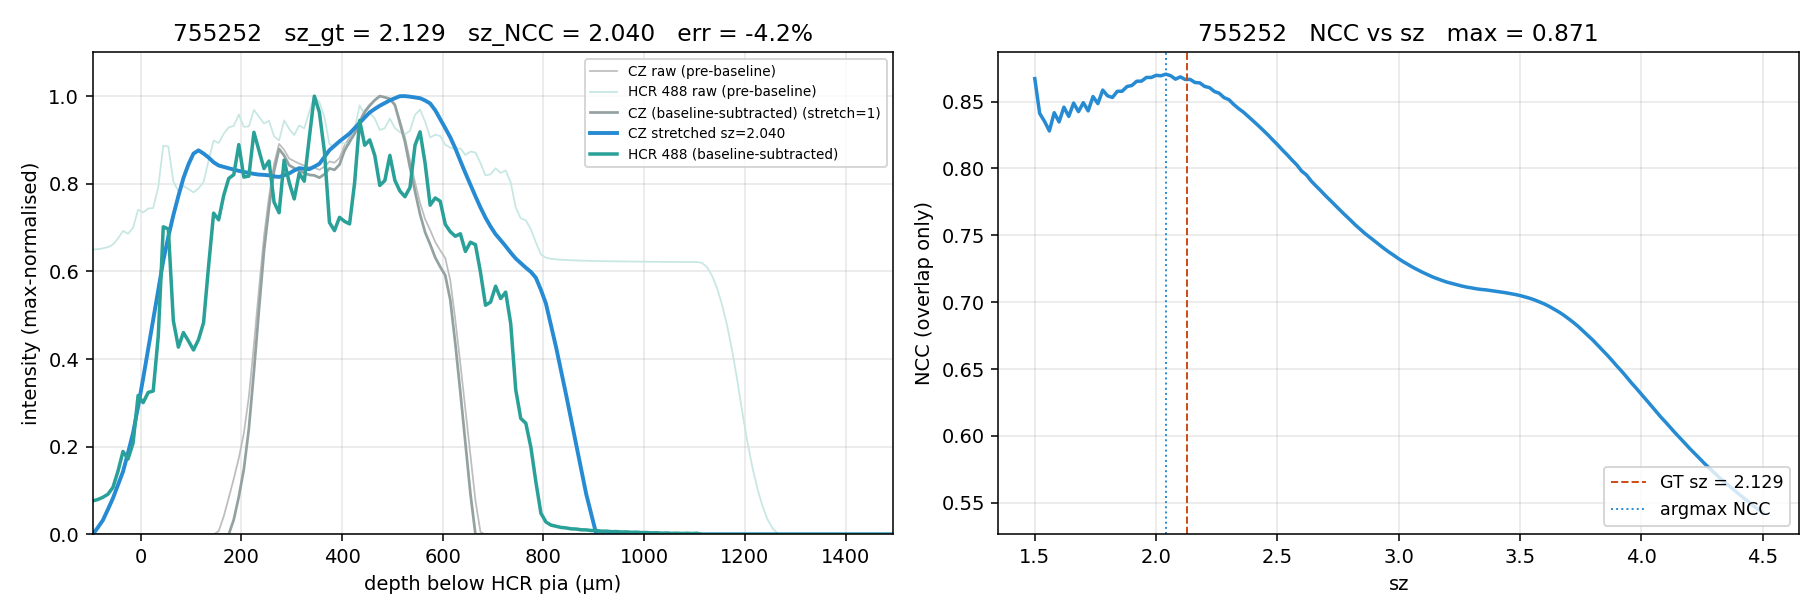

767018


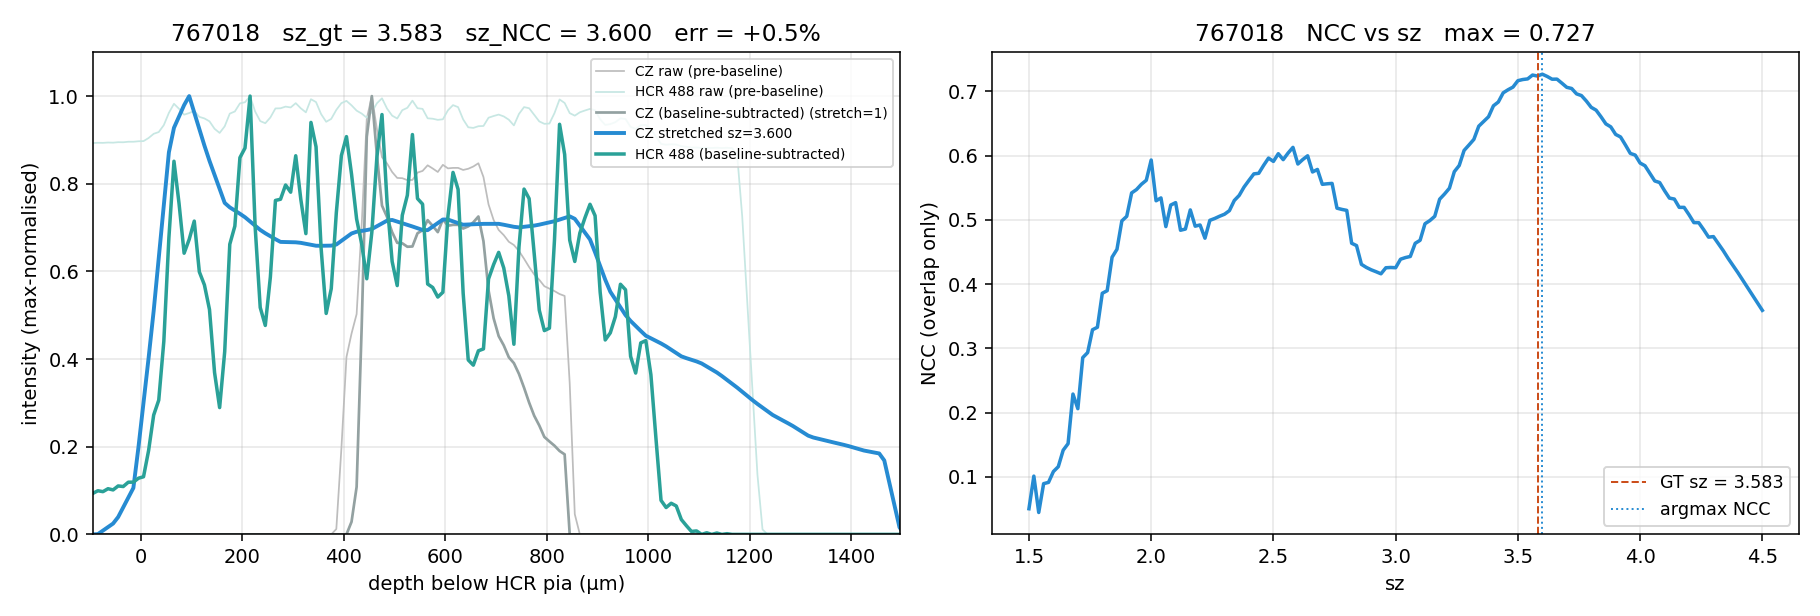

767022


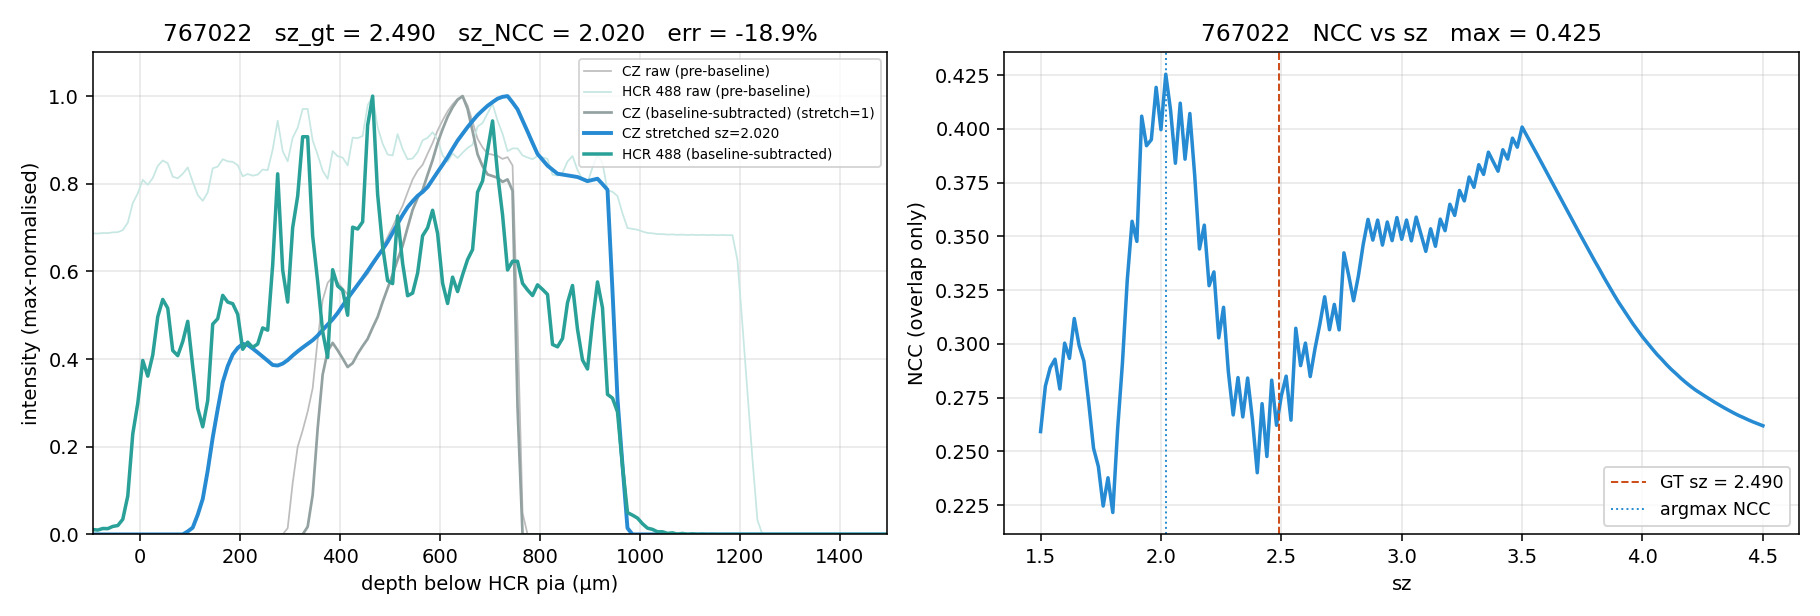

782149


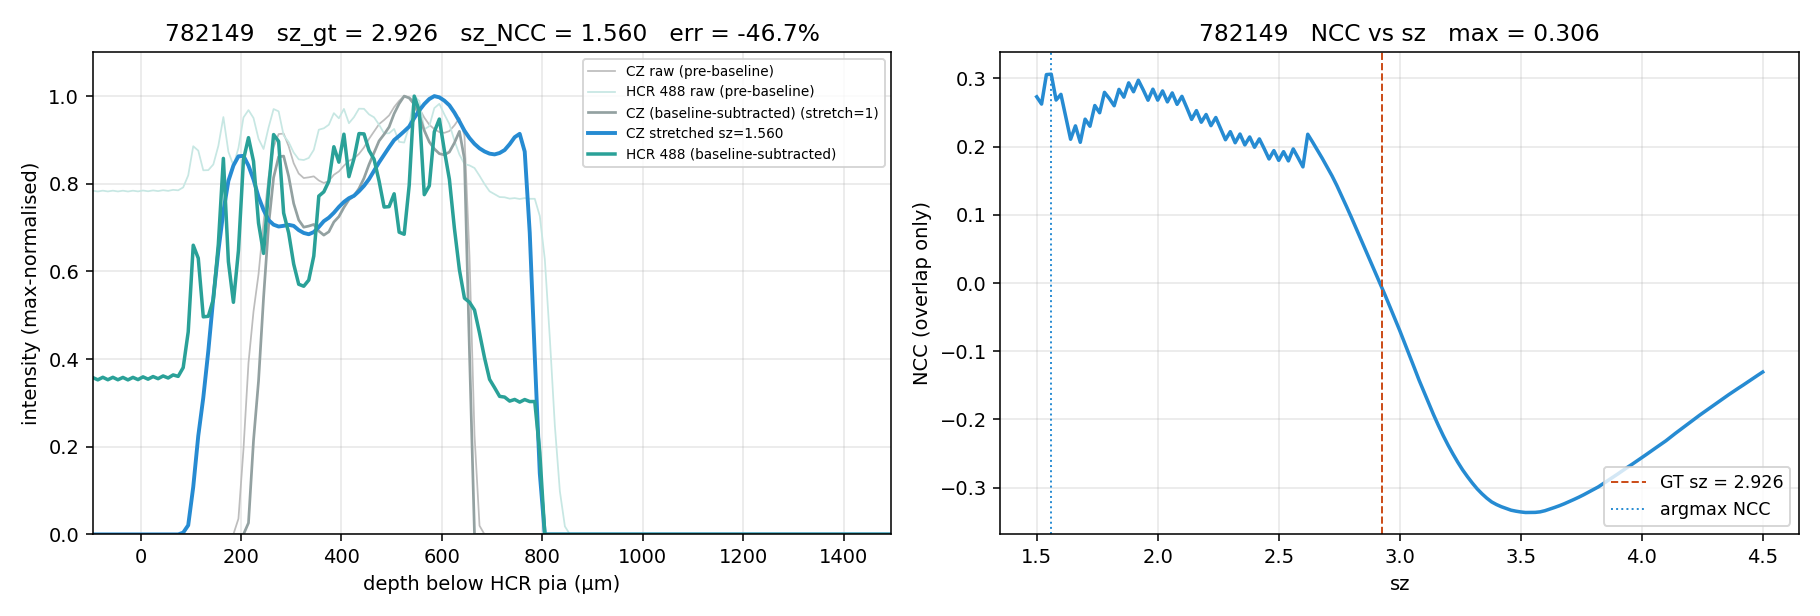

788406


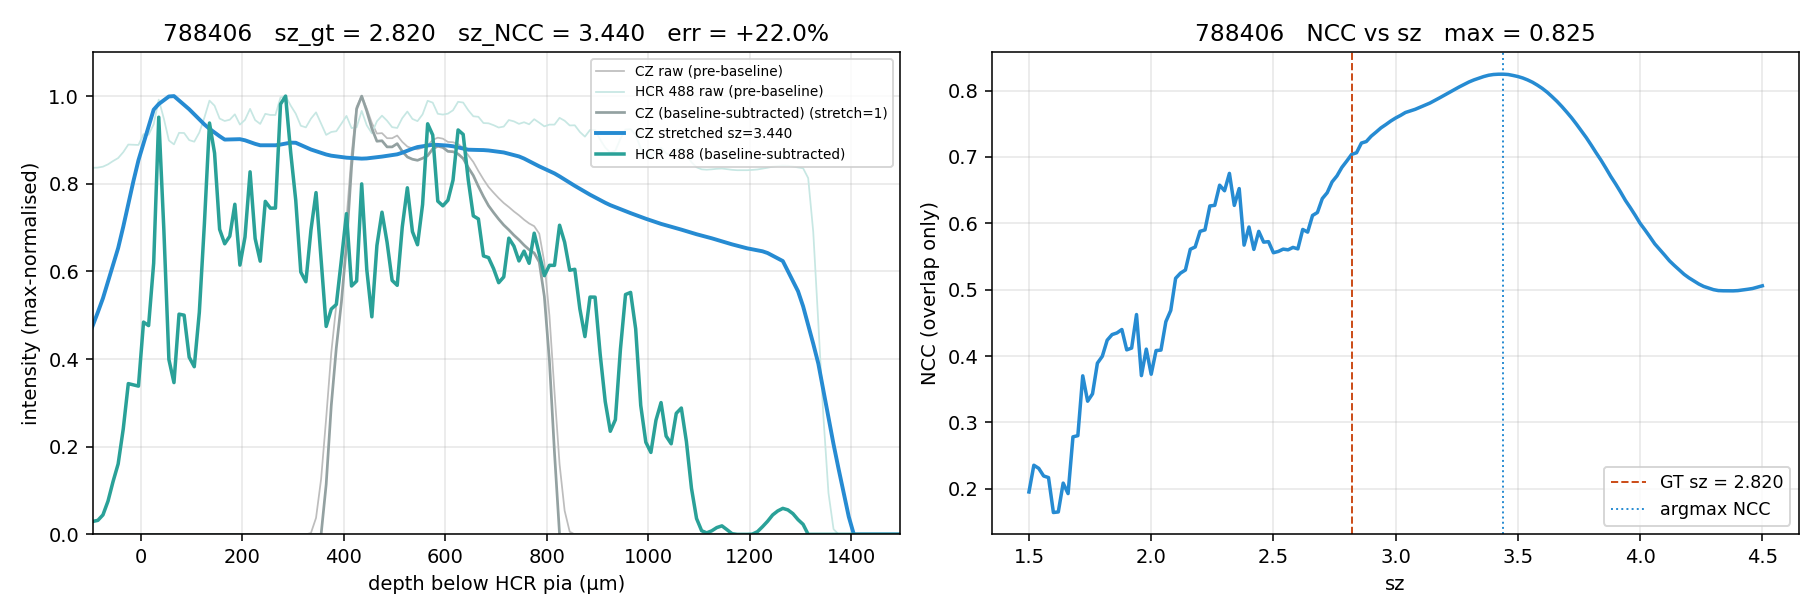

790322


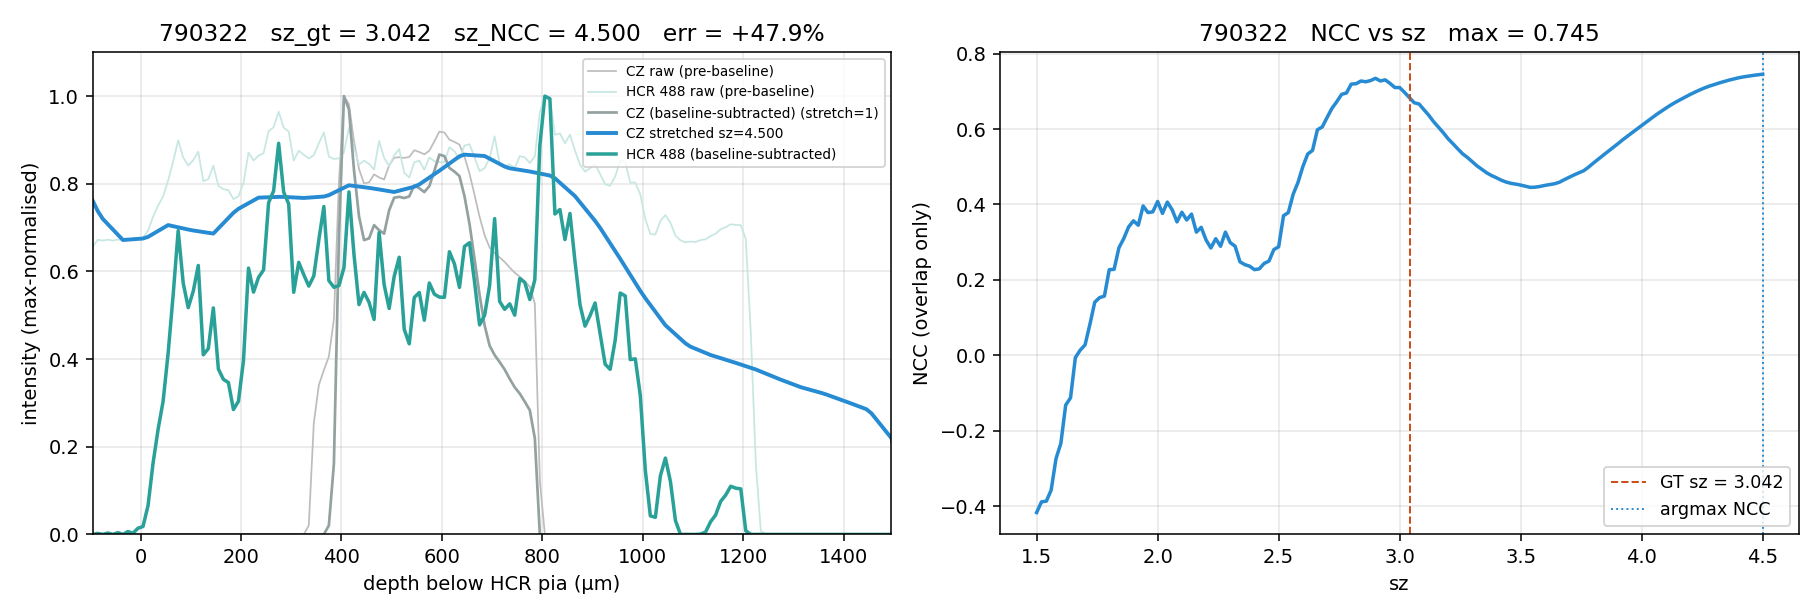

In [4]:
for sid in SUBJECTS:
    print(sid)
    p = SESSION / 'figures' / f'sz_ncc_488_baseline_{sid}.png'
    display(Image(str(p)))


## 4. Per-subject failure modes

- **755252 (PASS, 488+base, −4.2 %).** Raw 488 is a broad plateau;
  baseline subtraction sharpens it into a bell that matches CZ
  GCaMP shape. NCC anchors cleanly on the deep-end fall.

- **767018 (PASS, 488+base, +0.5 %).** Raw 488 is nearly flat —
  488-only-no-baseline railroads sz to the grid top (+39.5 %).
  Baseline reveals latent structure at the deep cortical end that
  anchors NCC at GT.

- **767022 (FAIL).** CZ and HCR 488 have different shapes that the
  1D profile cannot reconcile. Baseline subtraction erodes signal,
  dropping best-NCC to 0.425; the argmax at 2.02 is −18.9 %
  relative to GT 2.49.

- **782149 (FAIL, structural).** HCR z-extent is 1004 µm;
  GT-stretched CZ would need `450·2.93 = 1318 µm`. The physical
  match is **not inside the observed HCR volume**. NCC has no
  choice but to pick the smaller sz that fits CZ inside HCR —
  −37 to −47 % across all variants. No preprocessing can fix this.

- **788406 (FAIL).** HCR has a distinct fall-off at ~1600 µm;
  NCC prefers a larger sz to stretch CZ out to that edge
  (argmax 3.44 vs GT 2.82 in the best variant).

- **790322 (PASS in 488-only, FAIL in +baseline).** Raw 488 already
  has a clean plateau matching CZ GCaMP. Baseline subtraction
  introduces artificial peaks at tissue ends and pushes the
  argmax to the grid top (+47.9 %). The *no-preprocessing*
  variant is the right choice here.


In [5]:
# Z-extent table: when is HCR truncated relative to GT-stretched CZ?
cz_z_um = 450.0
hcr_z_um = {
    '755252': 1640, '767018': 1460, '767022': 1500,
    '782149': 1004, '788406': 1516, '790322': 1352,
}
rows = []
for sid in SUBJECTS:
    sz_gt = V488[sid]['sz_gt']
    needed = cz_z_um * sz_gt
    observed = hcr_z_um[sid]
    rows.append({
        'subject': sid,
        'cz_z_um': cz_z_um,
        'hcr_z_um': observed,
        'sz_gt': round(sz_gt, 3),
        'needed_to_fit_stretched_cz': round(needed, 0),
        'shortfall_pct': round(100 * (observed - needed) / needed, 1),
    })
pd.DataFrame(rows).set_index('subject')


,cz_z_um,hcr_z_um,sz_gt,needed_to_fit_stretched_cz,shortfall_pct
subject,,,,,
755252,450.0,1640,2.129,958.0,71.2
767018,450.0,1460,3.583,1612.0,-9.4
767022,450.0,1500,2.490,1120.0,33.9
782149,450.0,1004,2.926,1317.0,-23.8
788406,450.0,1516,2.820,1269.0,19.5
790322,450.0,1352,3.042,1369.0,-1.2


The `shortfall_pct` column is `(observed − needed)/needed`
in %. Negative = HCR too short. 782149 is structurally blocked
(−23.8 %); 767018 is marginal (−9 %); 790322 is borderline (+1 %).
The others have enough HCR depth for the 1D profile match to be
*possible*, but still fail on shape-mismatch grounds.


## 5. Verdict and next candidates

### What 07d showed
- Intensity-level NCC **does** bypass the centroid-threshold bias
  (06/07/07b/07c). No detection-shape contamination.
- A new ceiling appears: **CZ GCaMP vs HCR 488 depth-shape
  mismatch**. CZ is shallow GCaMP expression; HCR 488 is
  layer-retention + tissue-end fall. NCC aligns *shapes*, not
  physical stretch.
- A 1D depth profile collapses all xy structure into a scalar
  — exactly the information that would let NCC distinguish
  shape-sz from stretch-sz.
- HCR z-truncation on 782149 is a structural block independent
  of preprocessing.

### What's ruled out
Any **1D intensity-profile** variant (different channel, different
baseline, different smoothing). The 2/6 ceiling is set by shape
mismatch, not by preprocessing choice.

### Next candidates (each its own session — NOT implemented here)

**(a) 2D `I(x, d)` / `I(y, d)` NCC.** Optimise `(sxy, sz)` jointly
over 2D projections; recovers lateral structure (cell-dense
columns vs cell-sparse gaps) that a 1D profile averages away.
Robust to subjects with flat 1D profiles. ~30× more NCC
evaluations but tractable.

**(b) Segmentation-based layer-boundary matching.** Segment
cortical layers independently in each modality (DAPI-based in
HCR, peak-detection in CZ); match layer-boundary depths in µm.
Side-steps shape mismatch since both report the same boundary
location regardless of stain intensity. Requires a robust layer
segmentation — its own project.

**(c) Co-estimate sz from sxy + cell-count conservation.** If
sxy is well-constrained (e.g., from surface-projected 2D
matching), and total cell count is preserved under
coregistration, then `sz = N_ratio / sxy²`. Bypasses 782149's
truncation entirely — never matches stretched depth profiles.
